In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

In [118]:
# 1. 데이터 로드 및 전처리

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/WISDM.csv', names=['0', 'people', 'Class','timestamp','x','y','z'])
df = df.drop(['0', 'people', 'timestamp'], axis=1)
df = df[df['Class'].isin(['Jogging', 'Sitting'])]

In [119]:
df

,Class,x,y,z
0,Jogging,-0.694638,12.680544,0.503953
1,Jogging,5.012288,11.264028,0.953424
2,Jogging,4.903325,10.882658,-0.081722
3,Jogging,-0.612916,18.496431,3.023717
4,Jogging,-1.184970,12.108489,7.205164
...,...,...,...,...
1036605,Jogging,1.420000,-2.340000,1.950000
1036606,Jogging,-0.800000,0.230000,0.950000
1036607,Jogging,-0.110000,9.110000,-0.930000
1036608,Jogging,-2.560000,20.040000,0.080000


In [120]:
df.shape

(380851, 4)

In [121]:
# 결측치 홗인

df.isnull().values.any()

np.False_

In [122]:
LABELS = df['Class'].unique().tolist()
count_classes = df['Class'].value_counts(sort=True)

/tmp/ipython-input-2107955042.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  count_classes = pd.value_counts(df['Class'], sort = True)


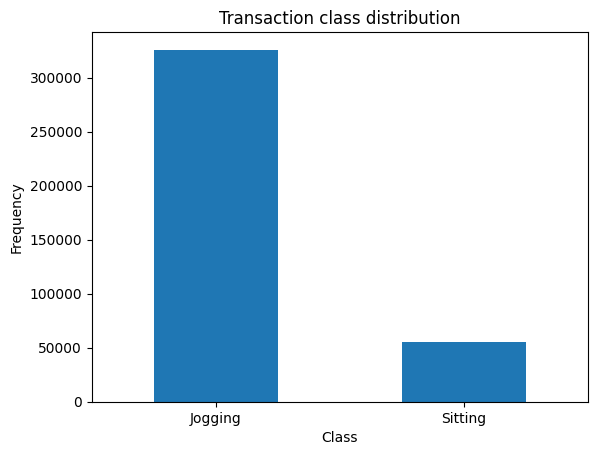

In [123]:
count_classes = pd.value_counts(df['Class'], sort = True)
count_classes.plot(kind = 'bar', rot=0)
plt.title("Transaction class distribution")
plt.xticks(range(2), LABELS)
plt.xlabel("Class")
plt.ylabel("Frequency");

In [124]:
frauds = df[df.Class == "Sitting"]
normal = df[df.Class == "Jogging"]
frauds.shape

(54876, 4)

In [125]:
normal.shape

(325975, 4)

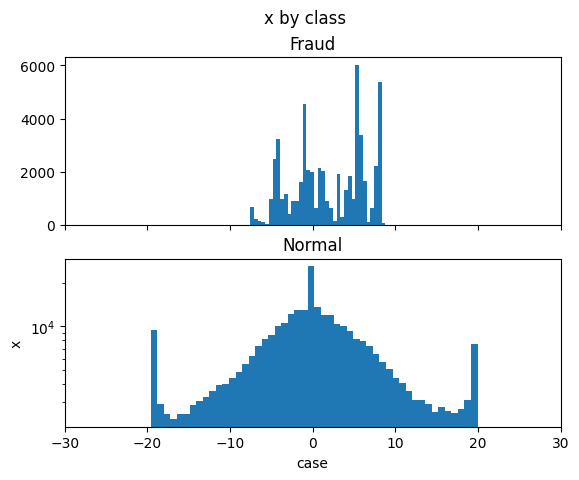

In [126]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle('x by class')

bins = 50

ax1.hist(frauds['x'], bins = bins)
ax1.set_title('Fraud')

ax2.hist(normal['x'], bins = bins)
ax2.set_title('Normal')

plt.xlabel('case')
plt.ylabel('x')
plt.xlim((-30, 30))
plt.yscale('log')
plt.show();

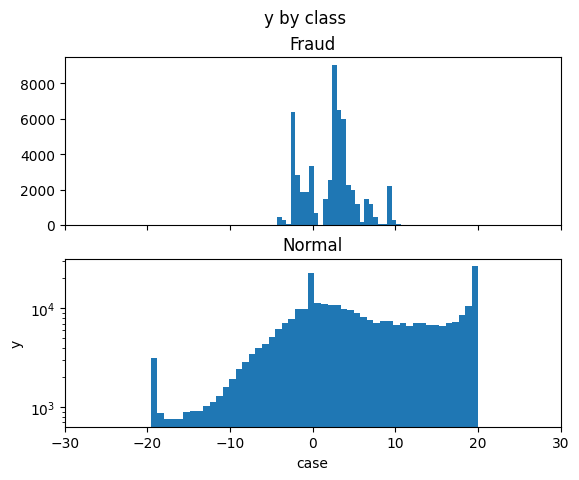

In [127]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle('y by class')

bins = 50

ax1.hist(frauds['y'], bins = bins)
ax1.set_title('Fraud')

ax2.hist(normal['y'], bins = bins)
ax2.set_title('Normal')

plt.xlabel('case')
plt.ylabel('y')
plt.xlim((-30, 30))
plt.yscale('log')
plt.show();

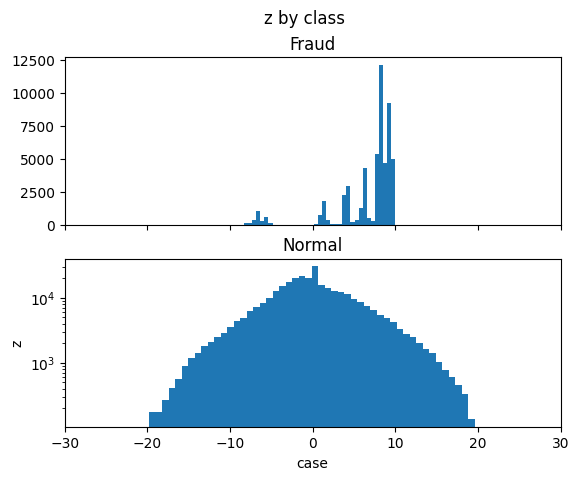

In [128]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle('z by class')

bins = 50

ax1.hist(frauds['z'], bins = bins)
ax1.set_title('Fraud')

ax2.hist(normal['z'], bins = bins)
ax2.set_title('Normal')

plt.xlabel('case')
plt.ylabel('z')
plt.xlim((-30, 30))
plt.yscale('log')
plt.show();

In [129]:
from sklearn.preprocessing import StandardScaler

data = df
data[['x', 'y', 'z']] = StandardScaler().fit_transform(data[['x', 'y', 'z']].values.reshape(-1, 3))

In [130]:
# 모델을 오직 정상 거래기록으로만 훈련
# 정상 거래기록을 테스트셋에 넣으면 모델의 성능을 평가

In [131]:
RANDOM_SEED = 42

In [132]:
X_train, X_test = train_test_split(data, test_size=0.2, random_state=RANDOM_SEED)
X_train = X_train[X_train.Class == "Jogging"]
X_train = X_train.drop(['Class'], axis=1)

y_test = X_test['Class']
X_test = X_test.drop(['Class'], axis=1)

X_train = X_train.values
X_test = X_test.values

X_train.shape

(260847, 3)

In [133]:
# 테스트 레이블을 남겨두는 이유는 나중에 정확도를 비교하기 위해서임

In [143]:
# 오토인코더 모델

input_dim = X_train.shape[1]
encoding_dim = 14  # 인코딩 차원을 설정 (임의로 설정한 값, 조정 가능)

input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)
encoded = Dense(int(encoding_dim / 2), activation='relu')(encoded)
decoded = Dense(int(encoding_dim / 2), activation='relu')(encoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

In [135]:
# 3. 모델 학습
# 훈련데이터의 0.1 을 validation data로 사용
history = autoencoder.fit(X_train, X_train,
                          epochs=50,
                          batch_size=256,
                          shuffle=True,
                          validation_split = 0.1)

Epoch 1/50
918/918 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.9716 - val_loss: 0.6349
Epoch 2/50
918/918 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.6370 - val_loss: 0.6331
Epoch 3/50
918/918 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.6379 - val_loss: 0.6326
Epoch 4/50
918/918 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.6366 - val_loss: 0.6324
Epoch 5/50
918/918 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.6369 - val_loss: 0.6322
Epoch 6/50
918/918 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.6365 - val_loss: 0.6318
Epoch 7/50
918/918 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.6385 - val_loss: 0.6313
Epoch 8/50
918/918 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.6380 - val_loss: 0.6311
Epoch 9/50
918/918 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.6368 - val_loss: 0.6311
Epoch 10/50
918/918 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.6327 - val_loss: 0.6310
Epoch 11/50
918/918 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.6341 - val_loss: 0.6310
Epoch 12/50
918/918 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

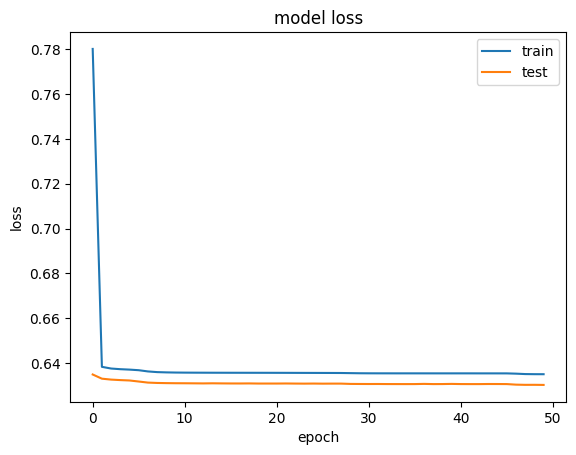

In [136]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper right');

In [144]:
# X_test 값을 넣어서 Reconstruction Error 값을 얻고,
# 실제 레이블인 y_test와 데이터프레임으로 구성
# Reconstruction Error + 실제 레이블의 형태가 됨

predictions = autoencoder.predict(X_test)
mse = np.mean(np.power(X_test - predictions, 2), axis=1)
error_df = pd.DataFrame({'reconstruction_error': mse,
                        'true_class': y_test})
error_df.describe()

2381/2381 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


,reconstruction_error
count,76171.000000
mean,1.215230
std,1.108106
min,0.000743
25%,0.501792
50%,0.829517
75%,1.568264
max,9.561834


In [145]:
error_df.head()

,reconstruction_error,true_class
106873,2.107742,Jogging
125283,0.500596,Jogging
634103,1.343954,Jogging
198929,2.035230,Jogging
422861,0.022860,Jogging


In [146]:
# threshold 값을 조정하여 최선의 정확도를 얻음, 그래프로를 보고 결정

threshold = 15

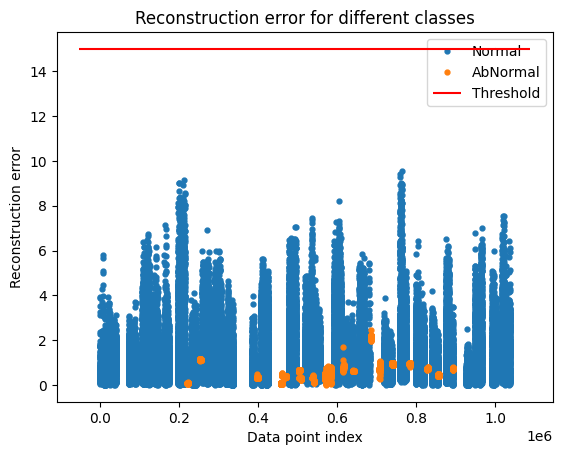

In [149]:
groups = error_df.groupby('true_class')
fig, ax = plt.subplots()

for name, group in groups:
    ax.plot(group.index, group.reconstruction_error, marker='o', ms=3.5, linestyle='',
            label= "AbNormal" if name == "Sitting" else "Normal")
ax.hlines(threshold, ax.get_xlim()[0], ax.get_xlim()[1], colors="r", zorder=100, label='Threshold')
ax.legend()
plt.title("Reconstruction error for different classes")
plt.ylabel("Reconstruction error")
plt.xlabel("Data point index")
plt.show();

In [147]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred = ["Jogging" if e > threshold else 0 for e in error_df.reconstruction_error.values]
conf_matrix = confusion_matrix(error_df.true_class, y_pred)
plt.figure(figsize=(8, 8))
sns.heatmap(conf_matrix, xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt="d");
plt.title("Confusion matrix")
plt.ylabel('True class')
plt.xlabel('Predicted class')
plt.show()

print(classification_report(error_df.true_class, y_pred))

TypeError: Labels in y_true and y_pred should be of the same type. Got y_true=['Jogging' 'Sitting'] and y_pred=[0]. Make sure that the predictions provided by the classifier coincides with the true labels.